/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Decision Tree Accuracy: 0.8062
Logistic Regression Accuracy: 0.8211

--- TOP 3 FEATURES DRIVING CHURN ---
tenure                         0.450624
InternetService_Fiber optic    0.341834
TotalCharges                   0.053667
dtype: float64


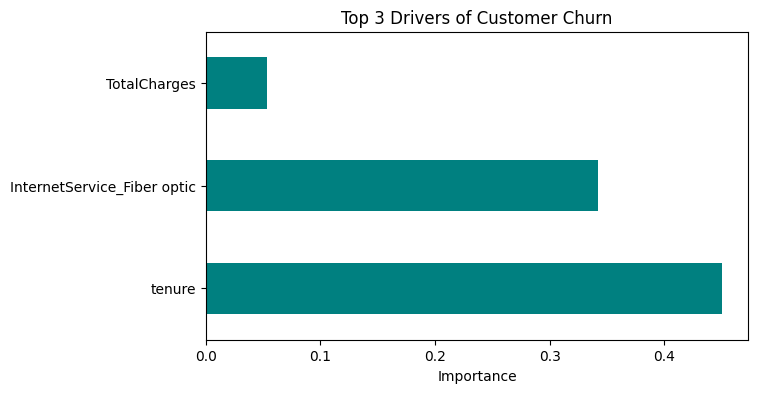

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 1. Load Dataset Directly
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

# Clean TotalCharges (Convert empty spaces to numeric)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Drop Customer ID
df = df.drop(columns=['customerID'])

# Convert Target (Churn: Yes/No to 1/0)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Encode Categorical Variables
df_encoded = pd.get_dummies(df, drop_first=True)

# Features and Target
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Train Decision Tree
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

# 3. Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

print(f"Decision Tree Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}\n")

# 4. Feature Importances (Top 3 Drivers for Decision Tree)
importances = pd.Series(dt_model.feature_importances_, index=X.columns)
top_3_features = importances.nlargest(3)

print("--- TOP 3 FEATURES DRIVING CHURN ---")
print(top_3_features)

# Plot Top Features
plt.figure(figsize=(7, 4))
top_3_features.plot(kind='barh', color='teal')
plt.title('Top 3 Drivers of Customer Churn')
plt.xlabel('Importance')
plt.show()